[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Dataset size: 7354


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

                                         description sentiment_label  \
0  The PROBLEM: So much entertainment today pushe...        POSITIVE   
1  Millions of American college students have stu...        POSITIVE   
2  Full A-Z Set I'm launching this set to show my...        NEGATIVE   
3  On a sleepy summer afternoon, we stared into t...        NEGATIVE   
4  48 hours of pledge matching! Amazing news! Two...        NEGATIVE   

   sentiment_score  
0         0.976869  
1         0.969020  
2         0.996028  
3         0.787522  
4         0.928495  

Sentiment distribution:
sentiment_label
POSITIVE    5641
NEGATIVE    1713
Name: count, dtype: int64


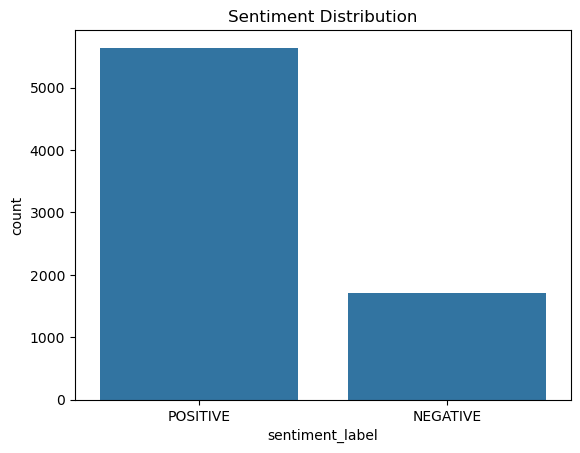

In [ ]:
import torch
import pandas as pd
from transformers import pipeline
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Kickstarter_processed.csv")  

df = df[df["description"].notna()]
df = df[df["description"].str.strip() != ""]

print("Dataset size:", len(df))

classifier = pipeline("sentiment-analysis")

texts = df["description"].tolist()
results = classifier(texts, truncation=True)

df["sentiment_label"] = [r["label"] for r in results]
df["sentiment_score"] = [r["score"] for r in results]

print(df[["description", "sentiment_label", "sentiment_score"]].head())

print("\nSentiment distribution:")
print(df["sentiment_label"].value_counts())

sns.countplot(x="sentiment_label", data=df)
plt.title("Sentiment Distribution")
plt.show()
df.to_csv("Kickstarter_with_bert_sentiment.csv", index=False)
